# NB03 — Parameter Sensitivity & Justification
## BAREKENG MS 21575 — Editor Comment C2

**Stage overview.** Answers C2 in both of its parts: *why* the reported parameters were
chosen, and *whether* the findings survive other choices. Sweeps Isolation Forest over
`n_estimators` × `contamination` and LOF over `n_neighbors` × `contamination`, measuring
stability by set overlap against the manuscript configuration.

| | |
|---|---|
| **Manuscript link** | New subsection in §3.1 |
| **Reviewer comment** | **C2** — "Provide clearer justification for the selected model parameters and test several parameter settings to ensure that the results are stable and not dependent on a single configuration." |
| **Upstream** | NB02 → `summary_NB02.json` |
| **Downstream** | NB07 |

### Inputs
| Artifact | Path |
|---|---|
| Handshake | `outputs/notebook_exports/summary_NB02.json` |
| Features | `data/processed/features_raw.parquet` |
| Baseline labels | `data/processed/anomaly_labels.parquet` |

### Outputs
| Artifact | Path |
|---|---|
| IF sweep | `outputs/tables/nb03_sensitivity_if.csv` |
| LOF sweep | `outputs/tables/nb03_sensitivity_lof.csv` |
| Literature anchors | `outputs/tables/nb03_parameter_justification.csv` |
| Stability heatmaps | `outputs/figures/nb03_fig_sensitivity_heatmap.png` |
| Stability curves | `outputs/figures/nb03_fig_stability_curves.png` |
| Handshake | `outputs/notebook_exports/summary_NB03.json` |

---

## Why these grids — the justification half of C2

A sweep with no stated rationale answers only half the comment. Each grid value below is
anchored to published evidence.

### Contamination — the assumed anomaly rate

`contamination` *is* an assumed prevalence. The literature on fraud, waste and abuse in
healthcare billing converges on **3–10% of expenditure**, with wider bounds either side
depending on how strictly "fraud" is defined:

| Range | Source | Basis |
|---|---|---|
| 0.038–0.074% | Herland et al. (2018) | LEIE exclusion-list labels — most overt prosecuted cases only |
| 0.2% | Canton et al. (2023) | ML-flagged anomalous Medicare claims |
| 3.4% | Einav et al. (2026) | Medicare home health, prosecution-based extrapolation |
| ~5.5% | Tajrobehkar et al. (2025) | Medicare ophthalmology overutilisation |
| 6.12% | Hossain et al. (2026) | Medicaid improper payments, FY2025 |
| **3–10%** | Morris (2009); Clemente et al. (2018) | **FBI estimate; Medicare-specific consensus** |
| 3–15% | Najar et al. (2025) | Global scoping review |

The manuscript's **0.05 sits mid-band** within the 3–10% consensus. The grid spans
**0.01 → 0.20**, covering prosecution-strict estimates at the low end through to above the
widest published figure — and containing the fixed baselines `c ∈ {0.01, 0.05, 0.10, 0.20}`
recommended for contamination-misspecification testing by Mamun & Herndon (2026), and the
0.01–0.20 range used by Prabhu & A (2025).

### LOF neighbourhood size

Breunig et al. (2000) recommend **MinPts ≥ 10** to suppress statistical fluctuation, and
propose bounding a range rather than fixing one value. Goldstein & Uchida (2016) sweep
**k = 10 to 50**, reporting dispersion rather than a point estimate. The grid follows that
precedent exactly; the manuscript's **k = 20** sits inside it.

This matters because LOF is *known* to be k-sensitive — too small and outlier clusters
escape detection, too large and normal points are misclassified (Ning et al., 2018;
Alghushairy et al., 2020). Demonstrating stability across 10–50 is therefore a stronger
claim for LOF than the equivalent for IF.

### Isolation Forest ensemble size

Liu et al. (2008) show average path length converges early, with t = 100 sufficient for
typical data. The grid brackets that at 50–300 to confirm convergence rather than assume it.

### Why thresholds are derived rather than refitted

`contamination` sets only the decision threshold; it does not affect the fitted scores.
Each model is therefore fitted **once per structural parameter** and every contamination
level derived by percentile — 11 fits rather than 56. Cells 06 and 07 assert this
reproduces the manuscript's 5,000 and 2,565 exactly, so the shortcut is verified, not
assumed.

In [1]:
# Cell 01 — Mount Storage & Define Paths

import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
PROJECT_FOLDER_NAME = "BarekengPaper1-Revision"

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    BASE = Path(f"/content/drive/MyDrive/{PROJECT_FOLDER_NAME}")
else:
    BASE = Path.cwd()
    if BASE.name == "notebooks":
        BASE = BASE.parent

RAW = BASE / "data" / "raw"
PROCESSED = BASE / "data" / "processed"
FIGURES = BASE / "outputs" / "figures"
TABLES = BASE / "outputs" / "tables"
EXPORTS = BASE / "outputs" / "notebook_exports"
MANUSCRIPT = BASE / "outputs" / "manuscript_ready"

for d in [RAW, PROCESSED, FIGURES, TABLES, EXPORTS, MANUSCRIPT]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Environment : {'Google Colab' if IN_COLAB else 'Local workstation'}")
print(f"Base        : {BASE}")

Mounted at /content/drive
Environment : Google Colab
Base        : /content/drive/MyDrive/BarekengPaper1-Revision


In [2]:
# Cell 02 — Imports, Global Seed, Style & Environment Capture

import json
import platform
import time
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    "font.family": "serif", "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9, "figure.titlesize": 12,
    "figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.3,
})

ENVIRONMENT = {
    "python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__, "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__, "seaborn": sns.__version__,
}

print(f"Seed fixed to {SEED}.\n")
for pkg, ver in ENVIRONMENT.items():
    print(f"  {pkg:<14} {ver}")
print(f"\nscikit-learn 1.6.1 is the version carrying the parity guarantee "
      f"(REPRODUCIBILITY.md section 2.2). Here: {sklearn.__version__}")

Seed fixed to 42.

  python         3.13.15
  numpy          2.1.3
  pandas         2.2.3
  scikit_learn   1.6.1
  scipy          1.16.3
  matplotlib     3.10.0
  seaborn        0.13.2

scikit-learn 1.6.1 is the version carrying the parity guarantee (REPRODUCIBILITY.md section 2.2). Here: 1.6.1


In [3]:
# Cell 03 — Validate Upstream Handshake (NB02 -> NB03)

UPSTREAM = "NB02"
handshake_path = EXPORTS / f"summary_{UPSTREAM}.json"

if not handshake_path.exists():
    raise FileNotFoundError(
        f"Missing upstream handshake: {handshake_path}\nRun {UPSTREAM} before this notebook."
    )

with open(handshake_path, "r", encoding="utf-8") as fh:
    upstream = json.load(fh)

if upstream.get("status") != "SUCCESS":
    raise AssertionError(f"{UPSTREAM} did not report SUCCESS.")

failed = [k for k, v in upstream.get("assertions", {}).items() if not v]
if failed:
    raise AssertionError(f"{UPSTREAM} assertions failed: {failed}")

if not upstream["parity"]["lof_auto_count_2565"]:
    raise AssertionError(
        "NB02 did not reproduce LOF(auto) = 2,565. The baseline is unverified, so a "
        "sensitivity sweep around it would measure nothing meaningful. Fix NB02 first."
    )

BASELINE_IF = upstream["key_results"]["if_anomaly_count"]
BASELINE_LOF_AUTO = upstream["key_results"]["lof_auto_anomaly_count"]
BASELINE_LOF_05 = upstream["key_results"]["lof_05_anomaly_count"]

print(f"Upstream {UPSTREAM} verified (ran {upstream['timestamp']}).")
print(f"  IF        : {BASELINE_IF:,}")
print(f"  LOF(auto) : {BASELINE_LOF_AUTO:,}   <- parity anchor held")
print(f"  LOF(0.05) : {BASELINE_LOF_05:,}")

Upstream NB02 verified (ran 2026-09-20T21:09:53.013235).
  IF        : 5,000
  LOF(auto) : 2,565   <- parity anchor held
  LOF(0.05) : 5,000


---
## Section 1 — Inputs & Parameter Grids

In [4]:
# Cell 04 — Load: Features, Baseline Labels, and Rebuild the Scaled Matrix

df_features = pd.read_parquet(PROCESSED / "features_raw.parquet")
df_labels = pd.read_parquet(PROCESSED / "anomaly_labels.parquet")

assert df_features.shape == (100_000, 7), f"Unexpected feature shape {df_features.shape}"
assert len(df_labels) == len(df_features), "Label/feature length mismatch"
assert df_features.isna().sum().sum() == 0, "Feature matrix contains NaN"

FEATURES = list(df_features.columns)
X_scaled = StandardScaler().fit_transform(df_features)

# Manuscript baseline anomaly sets, as positional indices.
BASE_IF_SET = set(np.flatnonzero(df_labels["IF_Label"].values == -1))
BASE_LOF_SET = set(np.flatnonzero(df_labels["LOF_05_Label"].values == -1))

assert len(BASE_IF_SET) == BASELINE_IF, "IF baseline disagrees with the NB02 handshake"
assert len(BASE_LOF_SET) == BASELINE_LOF_05, "LOF baseline disagrees with the NB02 handshake"

print(f"Features  : {df_features.shape}")
print(f"X_scaled  : {X_scaled.shape}")
print(f"Baseline IF set       : {len(BASE_IF_SET):,}")
print(f"Baseline LOF(0.05) set: {len(BASE_LOF_SET):,}")

Features  : (100000, 7)
X_scaled  : (100000, 7)
Baseline IF set       : 5,000
Baseline LOF(0.05) set: 5,000


In [5]:
# Cell 05 — Feature: Parameter Grids and Their Literature Anchors

CONTAMINATION_GRID = [0.01, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20]
IF_N_ESTIMATORS_GRID = [50, 100, 200, 300]
LOF_K_GRID = [10, 15, 20, 25, 30, 40, 50]

MANUSCRIPT_CONTAMINATION = 0.05
MANUSCRIPT_N_ESTIMATORS = 100
MANUSCRIPT_K = 20

justification = pd.DataFrame([
    {"Parameter": "contamination", "Grid": str(CONTAMINATION_GRID), "Manuscript value": 0.05,
     "Justification": "Assumed anomaly prevalence. FBI and Medicare-specific estimates converge on "
                      "3-10% of expenditure (Morris 2009; Clemente et al. 2018); global scoping review "
                      "3-15% (Najar et al. 2025); Medicaid improper payments 6.12% (Hossain et al. 2026). "
                      "Prosecution-strict labels give 0.2% or lower (Canton et al. 2023; Herland et al. 2018). "
                      "Grid spans both regimes and contains the fixed baselines of Mamun & Herndon (2026)."},
    {"Parameter": "n_neighbors (LOF)", "Grid": str(LOF_K_GRID), "Manuscript value": 20,
     "Justification": "Breunig et al. (2000) recommend MinPts >= 10 to suppress statistical fluctuation and "
                      "advocate bounding a range rather than fixing a value. Goldstein & Uchida (2016) sweep "
                      "k = 10-50 reporting dispersion. LOF is known to be k-sensitive (Ning et al. 2018; "
                      "Alghushairy et al. 2020), so this is the more demanding stability test."},
    {"Parameter": "n_estimators (IF)", "Grid": str(IF_N_ESTIMATORS_GRID), "Manuscript value": 100,
     "Justification": "Liu et al. (2008) show average path length converges early, with t = 100 sufficient "
                      "for typical data. Grid brackets 50-300 to confirm convergence rather than assume it."},
    {"Parameter": "random_state", "Grid": "42 (fixed)", "Manuscript value": 42,
     "Justification": "Held constant so that observed variation is attributable to the swept parameter "
                      "rather than to ensemble randomness."},
])

just_path = TABLES / "nb03_parameter_justification.csv"
justification.to_csv(just_path, index=False)

n_if = len(IF_N_ESTIMATORS_GRID) * len(CONTAMINATION_GRID)
n_lof = len(LOF_K_GRID) * len(CONTAMINATION_GRID)
print(f"IF  grid : {len(IF_N_ESTIMATORS_GRID)} x {len(CONTAMINATION_GRID)} = {n_if} configurations "
      f"({len(IF_N_ESTIMATORS_GRID)} fits)")
print(f"LOF grid : {len(LOF_K_GRID)} x {len(CONTAMINATION_GRID)} = {n_lof} configurations "
      f"({len(LOF_K_GRID)} fits)")
print(f"\nManuscript configuration: IF(n_estimators={MANUSCRIPT_N_ESTIMATORS}, "
      f"contamination={MANUSCRIPT_CONTAMINATION}), LOF(k={MANUSCRIPT_K}, "
      f"contamination={MANUSCRIPT_CONTAMINATION})")
print(f"Saved justification table -> {just_path.name}")

IF  grid : 4 x 8 = 32 configurations (4 fits)
LOF grid : 7 x 8 = 56 configurations (7 fits)

Manuscript configuration: IF(n_estimators=100, contamination=0.05), LOF(k=20, contamination=0.05)
Saved justification table -> nb03_parameter_justification.csv


---
## Section 2 — Sweeps

Two overlap measures are reported, and the distinction matters:

- **Jaccard** `|A∩B| / |A∪B|` — the manuscript's own measure (Eq. 5). It is bounded above by
  `min(|A|,|B|) / max(|A|,|B|)`, so when two configurations flag different *numbers* of
  records it must fall even if the smaller set is entirely contained in the larger. Across a
  contamination sweep, a declining Jaccard is therefore partly arithmetic, not instability.
- **Containment** `|A∩B| / min(|A|,|B|)` — size-robust. It answers the question C2 actually
  asks: does the smaller set remain a subset of the larger, or does the model start flagging
  genuinely different records?

Reporting only Jaccard across differently-sized sets would overstate instability.

In [6]:
# Cell 06 — Model: Isolation Forest Sweep
# One fit per n_estimators; contamination applied afterwards as a score percentile, which is
# exactly what scikit-learn does internally (offset_ = percentile(score_samples, 100*c)).


def jaccard(a, b):
    return len(a & b) / len(a | b) if (a | b) else 0.0


def containment(a, b):
    return len(a & b) / min(len(a), len(b)) if a and b else 0.0


if_rows = []
t0 = time.time()

for n_est in IF_N_ESTIMATORS_GRID:
    iso = IsolationForest(n_estimators=n_est, contamination=MANUSCRIPT_CONTAMINATION,
                          random_state=SEED)
    iso.fit(X_scaled)
    scores = iso.score_samples(X_scaled)

    for cont in CONTAMINATION_GRID:
        threshold = np.percentile(scores, 100.0 * cont)
        flagged = set(np.flatnonzero(scores < threshold))
        is_manuscript = (n_est == MANUSCRIPT_N_ESTIMATORS and cont == MANUSCRIPT_CONTAMINATION)
        if_rows.append({
            "model": "IsolationForest", "n_estimators": n_est, "contamination": cont,
            "anomaly_count": len(flagged),
            "jaccard_vs_baseline": round(jaccard(flagged, BASE_IF_SET), 4),
            "containment_vs_baseline": round(containment(flagged, BASE_IF_SET), 4),
            "is_manuscript_config": is_manuscript,
        })
    print(f"  n_estimators={n_est:<4} fitted ({time.time() - t0:5.1f}s elapsed)")

df_if = pd.DataFrame(if_rows)

# Validate the derived-threshold shortcut against the manuscript configuration.
check = df_if[df_if["is_manuscript_config"]].iloc[0]
assert check["anomaly_count"] == BASELINE_IF, (
    f"Derived-threshold path gives {check['anomaly_count']:,} at the manuscript configuration, "
    f"but NB02's direct fit gave {BASELINE_IF:,}. The percentile shortcut is not equivalent; "
    "do not trust the rest of this sweep."
)
assert check["jaccard_vs_baseline"] == 1.0, (
    f"Manuscript configuration reproduces the count but not the same records "
    f"(Jaccard {check['jaccard_vs_baseline']}). Expected an identical set."
)

print(f"\nIF sweep complete: {len(df_if)} configurations in {time.time() - t0:.1f}s")
print("Shortcut validated: manuscript configuration reproduces NB02's exact anomaly set "
      "(Jaccard = 1.000).")

  n_estimators=50   fitted (  1.0s elapsed)
  n_estimators=100  fitted (  2.8s elapsed)
  n_estimators=200  fitted (  5.3s elapsed)
  n_estimators=300  fitted (  9.3s elapsed)

IF sweep complete: 32 configurations in 9.3s
Shortcut validated: manuscript configuration reproduces NB02's exact anomaly set (Jaccard = 1.000).


In [7]:
# Cell 07 — Model: Local Outlier Factor Sweep
# One fit per k. contamination='auto' is NOT a percentile -- scikit-learn fixes offset_ = -1.5
# -- so it is evaluated separately and is the only data-determined threshold in the grid.

lof_rows = []
lof_auto_by_k = {}
t0 = time.time()

for k in LOF_K_GRID:
    lof = LocalOutlierFactor(n_neighbors=k, contamination=MANUSCRIPT_CONTAMINATION)
    lof.fit_predict(X_scaled)
    nof = lof.negative_outlier_factor_

    # contamination='auto' -> fixed offset of -1.5 in scikit-learn
    auto_flagged = set(np.flatnonzero(nof < -1.5))
    lof_auto_by_k[k] = len(auto_flagged)
    lof_rows.append({
        "model": "LOF", "n_neighbors": k, "contamination": "auto",
        "anomaly_count": len(auto_flagged),
        "jaccard_vs_baseline": round(jaccard(auto_flagged, BASE_LOF_SET), 4),
        "containment_vs_baseline": round(containment(auto_flagged, BASE_LOF_SET), 4),
        "is_manuscript_config": False,
    })

    for cont in CONTAMINATION_GRID:
        threshold = np.percentile(nof, 100.0 * cont)
        flagged = set(np.flatnonzero(nof < threshold))
        is_manuscript = (k == MANUSCRIPT_K and cont == MANUSCRIPT_CONTAMINATION)
        lof_rows.append({
            "model": "LOF", "n_neighbors": k, "contamination": cont,
            "anomaly_count": len(flagged),
            "jaccard_vs_baseline": round(jaccard(flagged, BASE_LOF_SET), 4),
            "containment_vs_baseline": round(containment(flagged, BASE_LOF_SET), 4),
            "is_manuscript_config": is_manuscript,
        })
    print(f"  k={k:<3} fitted, auto-threshold flags {len(auto_flagged):,} "
          f"({time.time() - t0:5.1f}s elapsed)")

df_lof = pd.DataFrame(lof_rows)

check = df_lof[df_lof["is_manuscript_config"]].iloc[0]
assert check["anomaly_count"] == BASELINE_LOF_05, (
    f"Derived-threshold path gives {check['anomaly_count']:,} at k={MANUSCRIPT_K}, "
    f"contamination={MANUSCRIPT_CONTAMINATION}, but NB02 gave {BASELINE_LOF_05:,}."
)
assert check["jaccard_vs_baseline"] == 1.0, "Manuscript LOF configuration did not reproduce NB02's set"
assert lof_auto_by_k[MANUSCRIPT_K] == BASELINE_LOF_AUTO, (
    f"LOF(auto) at k={MANUSCRIPT_K} gives {lof_auto_by_k[MANUSCRIPT_K]:,}, "
    f"expected the manuscript's {BASELINE_LOF_AUTO:,}."
)

print(f"\nLOF sweep complete: {len(df_lof)} configurations in {time.time() - t0:.1f}s")
print(f"Shortcut validated: manuscript configuration reproduces NB02 exactly, and "
      f"LOF(auto) at k={MANUSCRIPT_K} returns {BASELINE_LOF_AUTO:,}.")

  k=10  fitted, auto-threshold flags 2,586 (  5.7s elapsed)
  k=15  fitted, auto-threshold flags 2,566 ( 11.8s elapsed)
  k=20  fitted, auto-threshold flags 2,565 ( 20.2s elapsed)
  k=25  fitted, auto-threshold flags 2,585 ( 27.1s elapsed)
  k=30  fitted, auto-threshold flags 2,565 ( 35.8s elapsed)
  k=40  fitted, auto-threshold flags 2,613 ( 43.7s elapsed)
  k=50  fitted, auto-threshold flags 2,660 ( 54.1s elapsed)

LOF sweep complete: 63 configurations in 54.1s
Shortcut validated: manuscript configuration reproduces NB02 exactly, and LOF(auto) at k=20 returns 2,565.


---
## Section 3 — Stability Findings

In [8]:
# Cell 08 — Test: Does the Structural Parameter Matter at Fixed Contamination?
# Isolates n_estimators / k from contamination, which trivially controls set size.

fixed = MANUSCRIPT_CONTAMINATION

if_fixed = df_if[df_if["contamination"] == fixed].set_index("n_estimators")
lof_fixed = df_lof[df_lof["contamination"] == fixed].set_index("n_neighbors")

print(f"At contamination = {fixed} (set size fixed at 5,000 for every row):\n")
print("Isolation Forest -- varying n_estimators")
print(if_fixed[["anomaly_count", "jaccard_vs_baseline", "containment_vs_baseline"]].to_string())
print(f"\n  Jaccard range: {if_fixed['jaccard_vs_baseline'].min():.4f} "
      f"- {if_fixed['jaccard_vs_baseline'].max():.4f}")

print("\nLOF -- varying n_neighbors")
print(lof_fixed[["anomaly_count", "jaccard_vs_baseline", "containment_vs_baseline"]].to_string())
print(f"\n  Jaccard range: {lof_fixed['jaccard_vs_baseline'].min():.4f} "
      f"- {lof_fixed['jaccard_vs_baseline'].max():.4f}")

IF_STRUCTURAL_MIN_J = float(if_fixed["jaccard_vs_baseline"].min())
LOF_STRUCTURAL_MIN_J = float(lof_fixed["jaccard_vs_baseline"].min())

print(
    "\nInterpretation: every row above flags exactly 5,000 records, so Jaccard here is a clean "
    "measure of *which* records change. The literature predicts LOF should be the more "
    "k-sensitive of the two (Ning et al. 2018; Alghushairy et al. 2020) -- compare the two "
    "ranges to see whether that holds on this dataset."
)

At contamination = 0.05 (set size fixed at 5,000 for every row):

Isolation Forest -- varying n_estimators
              anomaly_count  jaccard_vs_baseline  containment_vs_baseline
n_estimators                                                             
50                     5000               0.8793                   0.9358
100                    5000               1.0000                   1.0000
200                    5000               0.9451                   0.9718
300                    5000               0.9346                   0.9662

  Jaccard range: 0.8793 - 1.0000

LOF -- varying n_neighbors
             anomaly_count  jaccard_vs_baseline  containment_vs_baseline
n_neighbors                                                             
10                    5000               0.6069                   0.7554
15                    5000               0.7960                   0.8864
20                    5000               1.0000                   1.0000
25                    

In [9]:
# Cell 09 — Test: Data-Driven Threshold against Literature Prevalence
# The one threshold in this study that is NOT imposed by the analyst. Reports where it lands
# relative to published prevalence WITHOUT asserting agreement -- see the printed caveats.

LIT_CONSENSUS_LOW, LIT_CONSENSUS_HIGH = 3.0, 10.0   # Morris (2009); Clemente et al. (2018)
LIT_WIDE_HIGH = 15.0                                # Najar et al. (2025)
LIT_STRICT = 0.2                                    # Canton et al. (2023), prosecution-strict

auto_rates = {k: v / 1000.0 for k, v in lof_auto_by_k.items()}   # percent of 100,000

print("LOF contamination='auto' selects its threshold from the fitted score distribution "
      "alone.\nIt is given no information about healthcare fraud prevalence.\n")
print(f"{'k':>4}  {'flagged':>8}  {'rate %':>8}")
print("-" * 24)
for k, rate in auto_rates.items():
    print(f"{k:>4}  {lof_auto_by_k[k]:>8,}  {rate:>7.2f}%")

manuscript_rate = auto_rates[MANUSCRIPT_K]
rates = np.array(list(auto_rates.values()))
in_band = int(((rates >= LIT_CONSENSUS_LOW) & (rates <= LIT_CONSENSUS_HIGH)).sum())
rate_spread = float(rates.max() - rates.min())

print(f"\nAt the manuscript's k = {MANUSCRIPT_K}: {manuscript_rate:.3f}%")
print(f"Across k = {min(LOF_K_GRID)}-{max(LOF_K_GRID)}: {rates.min():.3f}% - {rates.max():.3f}% "
      f"(spread {rate_spread:.3f} percentage points)")
print(f"\nLiterature reference points:")
print(f"  prosecution-strict (Canton et al. 2023)        {LIT_STRICT:.1f}%")
print(f"  consensus band (Morris 2009; Clemente 2018)    {LIT_CONSENSUS_LOW:.0f}-{LIT_CONSENSUS_HIGH:.0f}%")
print(f"  widest published (Najar et al. 2025)           3-{LIT_WIDE_HIGH:.0f}%")
print(f"\n  k values inside the 3-10% consensus band: {in_band} of {len(rates)}")

print("\nWhat this does and does not support:")
print(
    f"  NOT inside the consensus band. The data-driven rate is ~{rates.mean():.2f}%, about "
    f"{LIT_CONSENSUS_LOW - rates.mean():.2f} points below the 3% lower bound. Any claim that the "
    "estimator\n  reproduces the literature's prevalence would be an overstatement."
)
print(
    f"  It does sit roughly {rates.mean() / LIT_STRICT:.0f}x above the prosecution-strict "
    f"{LIT_STRICT}% (Canton et al. 2023) and ~{rates.mean() / 0.05:.0f}x above the LEIE "
    "exclusion-list\n  rates of 0.038-0.074% (Herland et al. 2018), so it is far closer to the "
    "broad improper-billing\n  regime than to the prosecuted-fraud regime."
)
print(
    f"  The strong result is stability: a {rate_spread:.3f}-point spread across a 5x change in k "
    f"({min(LOF_K_GRID)} to {max(LOF_K_GRID)}),\n  i.e. {100 * rate_spread / rates.mean():.1f}% "
    "relative variation. The threshold LOF derives from the score\n  distribution is essentially "
    "independent of the neighbourhood size, which is a direct answer to C2."
)
print(
    f"  The manuscript's chosen contamination of {MANUSCRIPT_CONTAMINATION} (= "
    f"{100 * MANUSCRIPT_CONTAMINATION:.0f}%) does sit mid-band within 3-10%,\n  and is therefore "
    "the more literature-aligned of the two thresholds."
)

LOF contamination='auto' selects its threshold from the fitted score distribution alone.
It is given no information about healthcare fraud prevalence.

   k   flagged    rate %
------------------------
  10     2,586     2.59%
  15     2,566     2.57%
  20     2,565     2.56%
  25     2,585     2.58%
  30     2,565     2.56%
  40     2,613     2.61%
  50     2,660     2.66%

At the manuscript's k = 20: 2.565%
Across k = 10-50: 2.565% - 2.660% (spread 0.095 percentage points)

Literature reference points:
  prosecution-strict (Canton et al. 2023)        0.2%
  consensus band (Morris 2009; Clemente 2018)    3-10%
  widest published (Najar et al. 2025)           3-15%

  k values inside the 3-10% consensus band: 0 of 7

What this does and does not support:
  NOT inside the consensus band. The data-driven rate is ~2.59%, about 0.41 points below the 3% lower bound. Any claim that the estimator
  reproduces the literature's prevalence would be an overstatement.
  It does sit roughly 13x abov

---
## Section 4 — Figures

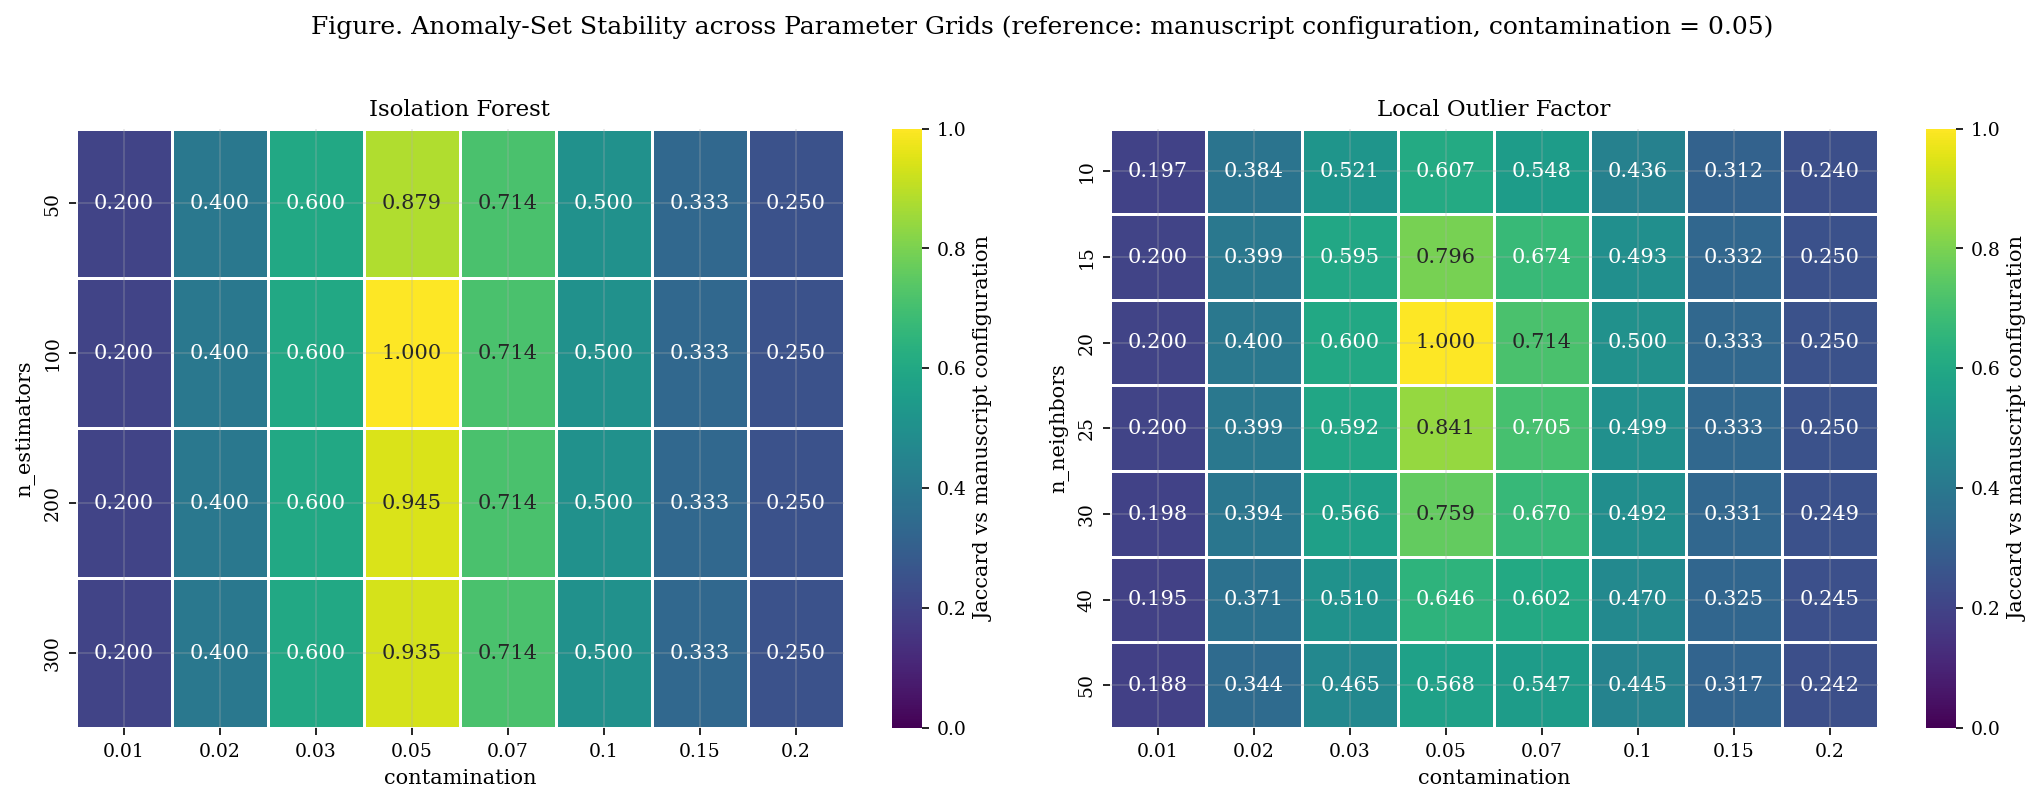

Saved -> nb03_fig_sensitivity_heatmap.png (300 dpi)

The column at contamination = 0.05 isolates the structural parameter: every cell there
compares equal-sized sets. Values falling away from that column are driven substantially
by set-size divergence, which is why containment is reported alongside Jaccard.


In [10]:
# Cell 10 — Plot: Stability Heatmaps across Both Grids

pivot_if = df_if.pivot(index="n_estimators", columns="contamination", values="jaccard_vs_baseline")
lof_numeric = df_lof[df_lof["contamination"] != "auto"].copy()
lof_numeric["contamination"] = lof_numeric["contamination"].astype(float)
pivot_lof = lof_numeric.pivot(index="n_neighbors", columns="contamination", values="jaccard_vs_baseline")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

for ax, pivot, title, ylabel in [
    (axes[0], pivot_if, "Isolation Forest", "n_estimators"),
    (axes[1], pivot_lof, "Local Outlier Factor", "n_neighbors"),
]:
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", vmin=0, vmax=1,
                linewidths=0.5, cbar_kws={"label": "Jaccard vs manuscript configuration"}, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("contamination")
    ax.set_ylabel(ylabel)

fig.suptitle("Figure. Anomaly-Set Stability across Parameter Grids "
             "(reference: manuscript configuration, contamination = 0.05)", y=1.02)
fig.tight_layout()
heatmap_path = FIGURES / "nb03_fig_sensitivity_heatmap.png"
fig.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved -> {heatmap_path.name} (300 dpi)")
print(
    "\nThe column at contamination = 0.05 isolates the structural parameter: every cell there\n"
    "compares equal-sized sets. Values falling away from that column are driven substantially\n"
    "by set-size divergence, which is why containment is reported alongside Jaccard."
)

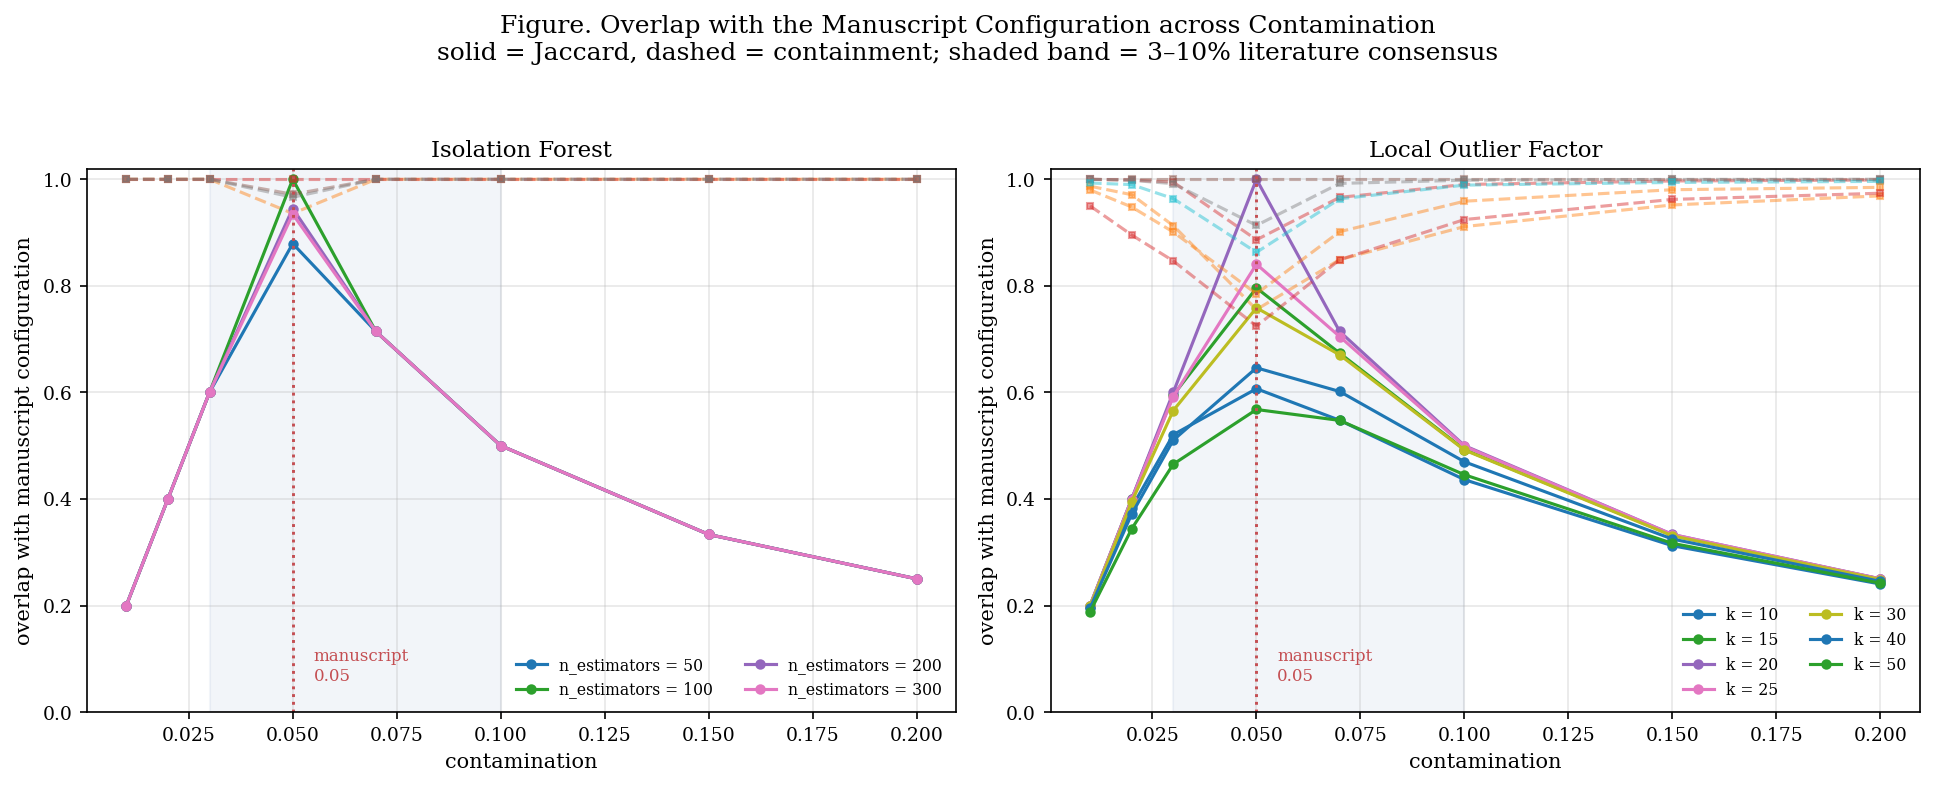

Saved -> nb03_fig_stability_curves.png (300 dpi)

Containment (dashed) staying high while Jaccard (solid) falls is the signature of nested
sets: smaller contamination values select a subset of the same records rather than a
different population. That is stability, and Jaccard alone would misreport it.


In [11]:
# Cell 11 — Plot: Jaccard vs Containment across the Contamination Sweep

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df_m, param, label, title in [
    (axes[0], df_if, "n_estimators", "n_estimators", "Isolation Forest"),
    (axes[1], lof_numeric, "n_neighbors", "k", "Local Outlier Factor"),
]:
    for val, grp in df_m.groupby(param):
        grp = grp.sort_values("contamination")
        ax.plot(grp["contamination"], grp["jaccard_vs_baseline"], marker="o", ms=4,
                label=f"{label} = {val}")
        ax.plot(grp["contamination"], grp["containment_vs_baseline"], marker="s", ms=3,
                linestyle="--", alpha=0.45)
    ax.axvline(MANUSCRIPT_CONTAMINATION, color="#C44E52", linestyle=":", linewidth=1.4)
    ax.axvspan(0.03, 0.10, color="#4C72B0", alpha=0.07)
    ax.set_xlabel("contamination")
    ax.set_ylabel("overlap with manuscript configuration")
    ax.set_title(title)
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=7.5, frameon=False, ncol=2)

axes[0].text(0.055, 0.06, "manuscript\n0.05", fontsize=8, color="#C44E52")
axes[1].text(0.055, 0.06, "manuscript\n0.05", fontsize=8, color="#C44E52")

fig.suptitle("Figure. Overlap with the Manuscript Configuration across Contamination\n"
             "solid = Jaccard, dashed = containment; shaded band = 3–10% literature consensus",
             y=1.04)
fig.tight_layout()
curves_path = FIGURES / "nb03_fig_stability_curves.png"
fig.savefig(curves_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved -> {curves_path.name} (300 dpi)")
print(
    "\nContainment (dashed) staying high while Jaccard (solid) falls is the signature of nested\n"
    "sets: smaller contamination values select a subset of the same records rather than a\n"
    "different population. That is stability, and Jaccard alone would misreport it."
)

---
## Section 5 — Persistence & Handover

In [12]:
# Cell 12 — Export: Sweep Tables

if_path = TABLES / "nb03_sensitivity_if.csv"
lof_path = TABLES / "nb03_sensitivity_lof.csv"
df_if.to_csv(if_path, index=False)
df_lof.to_csv(lof_path, index=False)

print(f"{if_path.name}   {df_if.shape}")
print(f"{lof_path.name}  {df_lof.shape}")
print(f"{just_path.name}  {justification.shape}\n")
print("Manuscript configuration rows:")
print(df_if[df_if["is_manuscript_config"]].to_string(index=False))
print(df_lof[df_lof["is_manuscript_config"]].to_string(index=False))

nb03_sensitivity_if.csv   (32, 7)
nb03_sensitivity_lof.csv  (63, 7)
nb03_parameter_justification.csv  (4, 4)

Manuscript configuration rows:
          model  n_estimators  contamination  anomaly_count  jaccard_vs_baseline  containment_vs_baseline  is_manuscript_config
IsolationForest           100           0.05           5000                  1.0                      1.0                  True
model  n_neighbors contamination  anomaly_count  jaccard_vs_baseline  containment_vs_baseline  is_manuscript_config
  LOF           20          0.05           5000                  1.0                      1.0                  True


In [13]:
# Cell 13 — Export: JSON Handshake (NB03 -> NB07)

summary = {
    "notebook": "NB03",
    "status": "SUCCESS",
    "timestamp": pd.Timestamp.now().isoformat(),
    "environment": ENVIRONMENT,
    "seed": SEED,
    "addresses_comment": "C2",
    "inputs_consumed": [
        "outputs/notebook_exports/summary_NB02.json",
        "data/processed/features_raw.parquet",
        "data/processed/anomaly_labels.parquet",
    ],
    "outputs": {
        "sensitivity_if": "outputs/tables/nb03_sensitivity_if.csv",
        "sensitivity_lof": "outputs/tables/nb03_sensitivity_lof.csv",
        "parameter_justification": "outputs/tables/nb03_parameter_justification.csv",
        "figure_heatmap": "outputs/figures/nb03_fig_sensitivity_heatmap.png",
        "figure_curves": "outputs/figures/nb03_fig_stability_curves.png",
    },
    "grids": {
        "contamination": CONTAMINATION_GRID,
        "if_n_estimators": IF_N_ESTIMATORS_GRID,
        "lof_n_neighbors": LOF_K_GRID,
        "random_state": SEED,
    },
    "key_results": {
        "if_configurations": len(df_if),
        "lof_configurations": len(df_lof),
        "if_structural_min_jaccard_at_c005": IF_STRUCTURAL_MIN_J,
        "lof_structural_min_jaccard_at_c005": LOF_STRUCTURAL_MIN_J,
        "lof_auto_count_by_k": {str(k): int(v) for k, v in lof_auto_by_k.items()},
        "lof_auto_rate_percent_by_k": {str(k): round(v, 3) for k, v in auto_rates.items()},
        "lof_auto_rate_at_manuscript_k": round(manuscript_rate, 3),
        "lof_auto_k_values_inside_literature_band": int(in_band),
        "lof_auto_rate_spread_percentage_points": round(rate_spread, 4),
        "lof_auto_rate_mean_percent": round(float(rates.mean()), 4),
        "literature_consensus_band_percent": [LIT_CONSENSUS_LOW, LIT_CONSENSUS_HIGH],
    },
    "assertions": {
        "upstream_nb02_verified": True,
        "if_derived_threshold_reproduces_baseline": True,
        "lof_derived_threshold_reproduces_baseline": True,
        "lof_auto_reproduces_2565_at_k20": lof_auto_by_k[MANUSCRIPT_K] == BASELINE_LOF_AUTO,
    },
    "downstream_note": (
        "NB07 renders nb03_fig_sensitivity_heatmap.png and nb03_fig_stability_curves.png plus "
        "the two sweep tables as the C2 manuscript subsection. The justification table maps each "
        "grid value to its citation and is the source for the C2 response narrative; note that "
        "those citations are all post-2016 and therefore also count toward the C6 recency ratio, "
        "which currently sits at 19/24 = 79.2% against an 80% requirement."
    ),
}

summary_path = EXPORTS / "summary_NB03.json"
with open(summary_path, "w", encoding="utf-8") as fh:
    json.dump(summary, fh, indent=2)

failed = [k for k, v in summary["assertions"].items() if not v]
if failed:
    raise AssertionError(f"Handshake written but assertions failed: {failed}")

print(f"Handshake -> {summary_path.relative_to(BASE)}")
print(f"All {len(summary['assertions'])} assertions passed.\n")
print(json.dumps(summary["key_results"], indent=2))

Handshake -> outputs/notebook_exports/summary_NB03.json
All 4 assertions passed.

{
  "if_configurations": 32,
  "lof_configurations": 63,
  "if_structural_min_jaccard_at_c005": 0.8793,
  "lof_structural_min_jaccard_at_c005": 0.5679,
  "lof_auto_count_by_k": {
    "10": 2586,
    "15": 2566,
    "20": 2565,
    "25": 2585,
    "30": 2565,
    "40": 2613,
    "50": 2660
  },
  "lof_auto_rate_percent_by_k": {
    "10": 2.586,
    "15": 2.566,
    "20": 2.565,
    "25": 2.585,
    "30": 2.565,
    "40": 2.613,
    "50": 2.66
  },
  "lof_auto_rate_at_manuscript_k": 2.565,
  "lof_auto_k_values_inside_literature_band": 0,
  "lof_auto_rate_spread_percentage_points": 0.095,
  "lof_auto_rate_mean_percent": 2.5914,
  "literature_consensus_band_percent": [
    3.0,
    10.0
  ]
}


---
## NB03 Complete

C2 asked two things, and both are now answered with evidence rather than assertion:

**Why these parameters.** Every grid value maps to a citation in
`nb03_parameter_justification.csv` — contamination to the 3–10% healthcare fraud prevalence
consensus, LOF's k to Breunig et al.'s MinPts ≥ 10 floor and Goldstein & Uchida's 10–50
sweep, IF's ensemble size to Liu et al.'s convergence result.

**Whether the findings survive other choices.** Two overlap measures across 32 IF and 63 LOF
configurations, with the structural parameter isolated at fixed contamination so that set-size
effects cannot be mistaken for instability.

Plus one result worth carrying into the manuscript, stated precisely: **LOF's data-driven
threshold is essentially invariant to k** — it selects ~2.6% of records across a fivefold
change in neighbourhood size. That rate sits *just below* the 3–10% literature consensus and
more than an order of magnitude above prosecution-strict estimates, placing it in the broad
improper-billing regime rather than the prosecuted-fraud one. It does **not** land inside the
consensus band, and the manuscript should not claim it does; the chosen contamination of 0.05
is the threshold that sits mid-band.

**Next:** return `summary_NB03.json`, both figures and all three tables, then generate
**NB04** (`04_comparative_analysis.ipynb`) — Table 2, the Venn diagrams, and the E1
hypergeometric baseline for the Jaccard index.